In [1]:
import pandas as pd
import ast

In [2]:
full_df = pd.read_csv("full_data_dump_merged.csv")

In [3]:
load_data = pd.read_csv('w_templ_analysis_dump_8B.csv')

In [4]:
merged_df = full_df.merge(
    load_data[["id", "template_id"]],
    on="id",
    how="left"
)

In [5]:
df = merged_df

In [6]:
df.head()

,id,query,ground_truths,status,deconstructed_facts,step2_entities_response,step3_relation_response,step3_relation_validation_response,entities,initial_symbol_candidates,relations,results,vss_merged_candidates,template_id
0,6517,Which cell structures are involved in interact...,"[56241, 55842, 56174, 56263]",SUCCESS,Target: The ANSWER is a cell structure.\nFact ...,"{\n ""ANSWER"": {\n ""name"": ""cell stru...","[\n (""ANSWER"", ""B"", ""interacts with""),\n (""B...","[\n (""A"", ""ANSWER"", ""interacts with""),\n (""B...","{""ANSWER"": {""type"": [""cellular_component""], ""l...",NaN,"{('A', 'ANSWER'): ['interacts with'], ('B', 'A...","{""answer_list"": [56174, 56241, 56263, 55842, 5...","[56174, 56241, 56263, 55842, 56436, 56160, 125...",22
1,9996,Which genes or proteins are expressed exclusiv...,[10833],SUCCESS,Target: The ANSWER is a gene or protein.\nFact...,"{\n ""ANSWER"": {\n ""name"": ""gene or p...","[\n (""ANSWER"", ""A"", ""expression present""),\n ...","[\n (""ANSWER"", ""C"", ""expression absent""),\n ...","{""ANSWER"": {""type"": [""gene/protein""], ""lexical...",NaN,"{('ANSWER', 'C'): ['expression absent'], ('ANS...","{""answer_list"": [61, 3387, 1403, 2773, 704, 10...","[61, 3387, 1403, 2773, 704, 10833, 2500, 1532,...",3
2,3630,Could you suggest any medications effective fo...,[15179],SUCCESS,Target: The ANSWER is a medication.\nFact 1: T...,"{\n ""ANSWER"": {\n ""name"": ""medicatio...","[\n (""ANSWER"", ""A"", ""indication""),\n (""ANSWE...","[\n (""ANSWER"", ""A"", ""indication""),\n (""ANSWE...","{""ANSWER"": {""type"": [""drug""], ""lexical"": {""nam...",NaN,"{('ANSWER', 'A'): ['indication'], ('ANSWER', '...","{""answer_list"": [14880, 20293, 15179, 15885, 2...","[14880, 20293, 15179, 15885, 20497, 14706, 141...",13
3,10252,Which gene or protein responsible for coding t...,"[43, 2140]",SUCCESS,Target: The ANSWER is a gene or protein.\nFact...,"{\n ""ANSWER"": {\n ""name"": ""gene or p...","[\n (""ANSWER"", ""A"", ""associated with""),\n (""...","[\n (""ANSWER"", ""C"", ""interacts with""),\n (""A...","{""ANSWER"": {""type"": [""gene/protein""], ""lexical...",NaN,"{('ANSWER', 'C'): ['interacts with'], ('ANSWER...","{""answer_list"": [13070, 43, 1641, 150, 1332, 1...","[13070, 43, 1641, 150, 1332, 12380, 152, 2689,...",17
4,5142,Which autosomal dominant diseases are linked t...,[30638],SUCCESS,Target: The ANSWER is an autosomal dominant di...,"{\n ""ANSWER"": {\n ""name"": ""autosomal...","[\n (""ANSWER"", ""A"", ""phenotype present"")\n]","[(""ANSWER"", ""A"", ""phenotype present"")]","{""ANSWER"": {""type"": [""disease""], ""lexical"": {""...",NaN,"{('ANSWER', 'A'): ['phenotype present']}","{""answer_list"": [32617, 28347, 28240, 33525, 3...","[32617, 28347, 28240, 33525, 30670, 30894, 283...",14


In [7]:
new_df = pd.DataFrame()
new_df["id"] = df["id"]
new_df["query"] = df["query"]
new_df["org_entities"]=df["entities"]
new_df["org_relations"]=df["relations"]
new_df["results"]=df["results"]
new_df["answer_list"]=df["vss_merged_candidates"]
new_df["ground_truths"]=df["ground_truths"]
new_df["results"]=new_df["results"].map(lambda x: ast.literal_eval(x))
new_df["retrieved_answer_list"] = new_df["results"].map(lambda x: x.get('answer_list', []))
new_df["retrieved_metrics"] = new_df["results"].map(lambda x: x["metrics"])
new_df["template_id"]=df["template_id"]

In [8]:
template_df  = pd.read_csv("prime_templates.csv")

In [9]:
new_df = new_df.merge(
    template_df,
    left_on="template_id",
    right_on="Id",
    how="left"   # keeps all rows from new_df
)

In [10]:
load_data = new_df

In [11]:
load_data["hit@1"] = load_data["retrieved_metrics"].map(lambda x: x['hit_at_1'])

In [12]:
load_data["hit@5"] = load_data["retrieved_metrics"].map(lambda x: x['hit_at_5'])

In [13]:
load_data["mrr"] = load_data["retrieved_metrics"].map(lambda x: x['mrr'])

In [14]:
load_data["recall@20"] = load_data["retrieved_metrics"].map(lambda x: x.get('recall@20', 0))

In [15]:
load_data["ground_truths"] = load_data["ground_truths"].map(lambda x: ast.literal_eval(x))

In [16]:
load_data["no_of_ground_truths"] = load_data["ground_truths"].map(lambda x: len(x))

In [17]:
max(load_data["no_of_ground_truths"])

18

In [18]:
def calculate_metrics(answers, ground_truths, k_values=None):
    """
    Calculate Hit@k, MRR, and Recall metrics.
    
    Parameters:
    -----------
    answers : list of lists
        Ranked list of answers for each query. 
        E.g., [['answer1', 'answer2', 'answer3'], ['answer4', 'answer5'], ...]
    
    ground_truths : list of lists or list of sets
        Ground truth answers for each query.
        E.g., [['true_ans1', 'true_ans2'], ['true_ans3'], ...]
    
    k_values : list, optional
        List of k values for Hit@k calculation. Default: [1, 5]
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'hit@k': dict with hit rates for each k
        - 'mrr': mean reciprocal rank
        - 'recall': mean recall
        - 'num_queries': number of queries evaluated
    """
    if k_values is None:
        k_values = [1, 5]
    
    total_hit = {k: 0.0 for k in k_values}
    total_mrr = 0.0
    total_recall = 0.0
    num_queries = len(answers)
    
    for query_answers, query_ground_truth in zip(answers, ground_truths):
        # Convert to sets for easier comparison
        gt_set = set(query_ground_truth) if not isinstance(query_ground_truth, set) else query_ground_truth
        
        # Calculate Hit@k
        for k in k_values:
            top_k = set(query_answers[:k])
            if len(gt_set & top_k) > 0:  # If there's any intersection
                total_hit[k] += 1
        
        # Calculate MRR (Mean Reciprocal Rank)
        mrr = 0.0
        for rank, answer in enumerate(query_answers, 1):
            if answer in gt_set:
                mrr = 1.0 / rank
                break
        total_mrr += mrr
        
        # Calculate Recall
        if len(gt_set) > 0:
            retrieved = set(query_answers)
            num_relevant_retrieved = len(gt_set & retrieved)
            recall = num_relevant_retrieved / len(gt_set)
            total_recall += recall
    
    # Calculate averages
    avg_hit = {k: (total_hit[k] / num_queries if num_queries > 0 else 0.0) for k in k_values}
    avg_mrr = total_mrr / num_queries if num_queries > 0 else 0.0
    avg_recall = total_recall / num_queries if num_queries > 0 else 0.0
    
    return {
        'hit@k': avg_hit,
        'mrr': avg_mrr,
        'recall': avg_recall,
        'num_queries': num_queries
    }


# Example usage:
# answers = [['ans1', 'ans2', 'ans3', 'ans4', 'ans5'], ['ans6', 'ans7']]
# ground_truths = [['ans1', 'ans3'], ['ans7']]
# metrics = calculate_metrics(answers, ground_truths, k_values=[1, 5])
# print(metrics)


In [19]:
# Extract vss_merged_candidates and ground_truths from dataframe columns
vss_merged_candidates_list = []
ground_truths_list = []

for idx, row in load_data.iterrows():
    # Get vss_merged_candidates from column
    candidates = row['retrieved_answer_list']
    if isinstance(candidates, str):
        try:
            candidates = eval(candidates)
        except:
            candidates = []
    vss_merged_candidates_list.append(candidates if isinstance(candidates, list) else [])
    
    # Get ground_truths from column
    ground_truth = row['ground_truths']
    if isinstance(ground_truth, str):
        try:
            ground_truth = eval(ground_truth)
        except:
            ground_truth = []
    ground_truths_list.append(ground_truth if isinstance(ground_truth, list) else [])

# Calculate metrics for all data
vss_all_metrics = calculate_metrics(vss_merged_candidates_list, ground_truths_list, k_values=[1, 5, 10, 20])

print("=== Metrics for All Data (from DataFrame) ===")
print(f"Hit@1:  {vss_all_metrics['hit@k'][1]:.4f}")
print(f"Hit@5:  {vss_all_metrics['hit@k'][5]:.4f}")
print(f"Hit@10: {vss_all_metrics['hit@k'][10]:.4f}")
print(f"Hit@20: {vss_all_metrics['hit@k'][20]:.4f}")
print(f"MRR:    {vss_all_metrics['mrr']:.4f}")
print(f"Recall: {vss_all_metrics['recall']:.4f}")
print(f"Total Queries: {vss_all_metrics['num_queries']}")


=== Metrics for All Data (from DataFrame) ===
Hit@1:  0.2929
Hit@5:  0.4821
Hit@10: 0.5607
Hit@20: 0.6250
MRR:    0.3776
Recall: 0.5749
Total Queries: 280


In [21]:
df = load_data

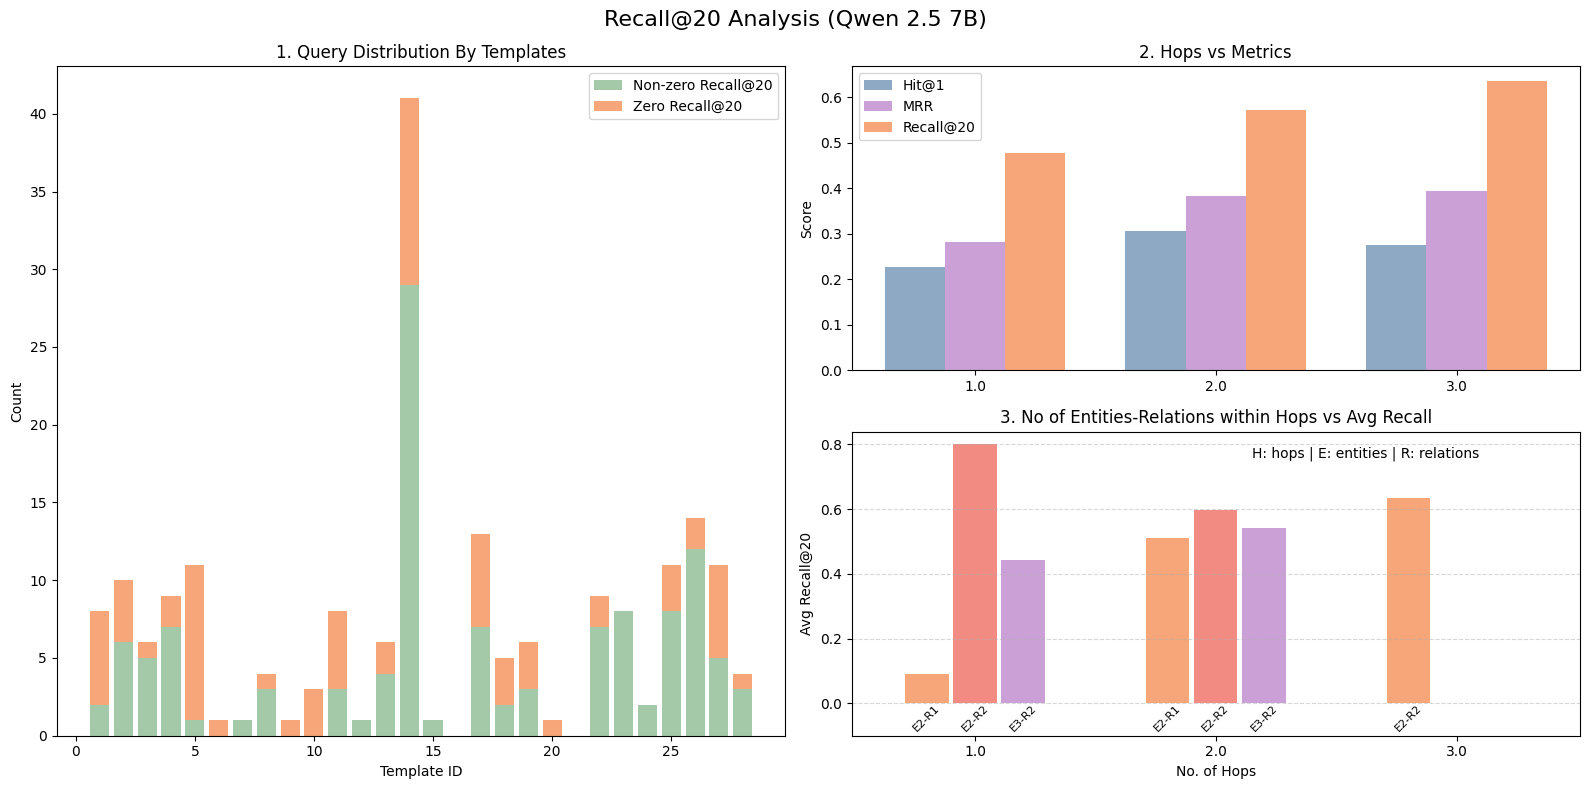

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# --- preprocessing ---
df['template_id'] = pd.to_numeric(df['template_id'], errors='coerce')
df['recall@20'] = pd.to_numeric(df['recall@20'], errors='coerce')
df['hit@1'] = pd.to_numeric(df['hit@1'], errors='coerce')
df['mrr'] = pd.to_numeric(df['mrr'], errors='coerce')
df['No_of_hops'] = pd.to_numeric(df['No_of_hops'], errors='coerce')

df['success'] = (df['recall@20'] > 0).astype(int)

# =========================
# 1. TEMPLATE-WISE
# =========================
tpl = df[df['template_id'] != 0].groupby('template_id').agg(
    total=('template_id', 'size'),
    success=('success', 'sum')
).reset_index()

tpl = tpl[tpl['total'] > 0]
tpl['failure'] = tpl['total'] - tpl['success']

# =========================
# 2. HOPS vs METRICS
# =========================
hops_agg = df.groupby('No_of_hops')[['hit@1', 'mrr', 'recall@20']].mean().reset_index()

# =========================
# 3. STRUCTURE (H grouped, then E-R)
# =========================
grp = df.groupby(['No_of_hops', 'No_of_entities', 'No_of_relations']).agg(
    avg_recall=('recall@20', 'mean'),
    count=('recall@20', 'size')
).reset_index()

grp = grp[grp['count'] >= 5]  # optional filter

grp = grp.sort_values(['No_of_hops', 'No_of_entities', 'No_of_relations'])

# =========================
# 📊 FIGURE LAYOUT
# =========================
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(2, 2, width_ratios=[1, 1])


# Overall figure title
fig.suptitle("Recall@20 Analysis (Qwen 2.5 7B)", fontsize=16)

# --- LEFT: TEMPLATE (FULL HEIGHT) ---
# color_map
color_map = {
    'relation_error': '#f6a678',        # soft orange
    'entity_error': '#f28b82',          # muted red
    'entity+relation_error': '#cba0d7', # soft lavender/purple
    'partial_retrieval': '#8da9c4',     # muted blue
    'success': '#a3c9a8'                # soft green
}

# --- LEFT: TEMPLATE (FULL HEIGHT) ---
ax1 = fig.add_subplot(gs[:, 0])

ax1.bar(tpl['template_id'], tpl['success'], color=color_map['success'], label='Non-zero Recall@20')
ax1.bar(tpl['template_id'], tpl['failure'], bottom=tpl['success'], color=color_map['relation_error'], label='Zero Recall@20')

ax1.set_title('1. Query Distribution By Templates')
ax1.set_xlabel('Template ID')
ax1.set_ylabel('Count')
ax1.legend()

# =========================
# RIGHT TOP: HOPS vs METRICS
# Use muted colors from the palette for consistency
ax2 = fig.add_subplot(gs[0, 1])

x = np.arange(len(hops_agg))
width = 0.25

ax2.bar(x - width, hops_agg['hit@1'], width, label='Hit@1', color=color_map['partial_retrieval'])
ax2.bar(x, hops_agg['mrr'], width, label='MRR', color=color_map['entity+relation_error'])
ax2.bar(x + width, hops_agg['recall@20'], width, label='Recall@20', color=color_map['relation_error'])

ax2.set_xticks(x)
ax2.set_xticklabels(hops_agg['No_of_hops'])

ax2.set_title('2. Hops vs Metrics')
ax2.set_ylabel('Score')
ax2.legend()

# =========================
# RIGHT BOTTOM: HOPS → (E-R GROUPED)
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)

x = np.arange(len(hops_agg))
group_width = 0.6

# Use a list of soft colors to cycle bars
er_colors = [color_map['relation_error'], color_map['entity_error'], color_map['entity+relation_error'],
             color_map['partial_retrieval'], color_map['success']]

# Number of categories per group (max across all hops)
max_categories = 3

for i, h in enumerate(hops_agg['No_of_hops']):
    subset = grp[grp['No_of_hops'] == h]
    n = len(subset)

    bar_width = group_width / max_categories
    offsets = np.linspace(-group_width/2 + bar_width/2,
                          group_width/2 - bar_width/2,
                          max_categories)

    for j in range(max_categories):
        if j < n:
            row = subset.iloc[j]
            ax3.bar(
                x[i] + offsets[j],
                row['avg_recall'],
                width=bar_width*0.9,
                color=er_colors[j % len(er_colors)]
            )
            ax3.text(
                x[i] + offsets[j],
                0,
                f"E{int(row['No_of_entities'])}-R{int(row['No_of_relations'])}",
                ha='center',
                va='top',
                fontsize=8,
                rotation=45
            )
        else:
            # Empty bar placeholder to keep width uniform
            ax3.bar(
                x[i] + offsets[j],
                0,
                width=bar_width*0.9,
                color='white',
                edgecolor='none'
            )

ax3.set_xticks(x)
ax3.set_xticklabels(hops_agg['No_of_hops'])
ax3.set_title('3. No of Entities-Relations within Hops vs Avg Recall')
ax3.set_xlabel('No. of Hops')
ax3.set_ylabel('Avg Recall@20')
ax3.set_ylim(bottom=-0.1)
ax3.text(0.55, 0.95, 'H: hops | E: entities | R: relations', transform=ax3.transAxes, verticalalignment='top')
ax3.grid(axis='y', linestyle='--', alpha=0.5)

# Save figure as SVG
fig.savefig("final_result_analysis.png", format='png')

plt.tight_layout()
plt.show()

In [25]:
import json

def safe_parse(x):
    # handle NaN
    if pd.isna(x):
        return {}
    
    # already dict
    if isinstance(x, dict):
        return x
    
    # try JSON
    if isinstance(x, str):
        try:
            return json.loads(x)
        except:
            try:
                x_fixed = x.replace("false", "False").replace("true", "True").replace("null", "None")
                return ast.literal_eval(x_fixed)
            except:
                return {}
    
    return {}

In [26]:
df['org_entities'] = df['org_entities'].apply(safe_parse)
df['org_relations'] = df['org_relations'].apply(safe_parse)

In [27]:
df['org_entities'][0]

{'ANSWER': {'type': ['cellular_component'],
  'lexical': {'name': 'cell structure'},
  'semantic': ['cell structure that interacts with an intermediate gene/protein influenced by Travoprost'],
  'constant': False},
 'A': {'type': ['drug'],
  'lexical': {'name': 'Travoprost'},
  'semantic': ['medication that influences an intermediate gene/protein'],
  'constant': True},
 'B': {'type': ['gene/protein'],
  'lexical': {'name': 'unknown gene/protein X'},
  'semantic': ['intermediate gene/protein influenced by Travoprost and interacted with by the ANSWER'],
  'constant': False}}

In [28]:
def extract_entity_info(org_entities):

    types = set()
    for ent in org_entities.values():
        for t in ent.get("type", []):
            types.add(t)

    return len(types), sorted(types)


def extract_relation_info(org_relations):
    
    rel_types = set()
    for rel_list in org_relations.values():
        for r in rel_list:
            rel_types.add(r)

    return len(rel_types), sorted(rel_types)

In [29]:
df['org_entity_info'] = df['org_entities'].apply(extract_entity_info)
df['org_relation_info'] = df['org_relations'].apply(extract_relation_info)

df['org_num_entity_types'] = df['org_entity_info'].apply(lambda x: x[0])
df['org_entity_types'] = df['org_entity_info'].apply(lambda x: x[1])

df['org_num_relation_types'] = df['org_relation_info'].apply(lambda x: x[0])
df['org_relation_types'] = df['org_relation_info'].apply(lambda x: x[1])

In [30]:
def get_paths_with_relations(relations_str):
    import pandas as pd
    from collections import deque
    import json, ast

    # safe parse
    def safe_parse(x):
        if pd.isna(x):
            return {}
        if isinstance(x, dict):
            return x
        if isinstance(x, str):
            try:
                return json.loads(x)
            except:
                try:
                    x_fixed = x.replace("false", "False").replace("true", "True").replace("null", "None")
                    return ast.literal_eval(x_fixed)
                except:
                    return {}
        return {}

    rel_dict = safe_parse(relations_str)

    if not isinstance(rel_dict, dict) or not rel_dict:
        return None

    # 🔥 Build graph WITH relation types
    graph = {}
    query_entities = set()

    for (src, dst), relations in rel_dict.items():
        rel = relations[0] if relations else "unknown"

        graph.setdefault(src, []).append((dst, rel))
        graph.setdefault(dst, []).append((src, rel))  # undirected

        if src != 'ANSWER':
            query_entities.add(src)
        if dst != 'ANSWER':
            query_entities.add(dst)

    if 'ANSWER' not in graph or not query_entities:
        return None

    # BFS with relation tracking
    def bfs(start, end):
        queue = deque([(start, [])])  # (node, path_edges)
        visited = {start}

        while queue:
            node, path = queue.popleft()

            if node == end:
                return path

            for neighbor, rel in graph.get(node, []):
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append((neighbor, path + [(node, rel, neighbor)]))

        return None

    # build paths
    paths = []

    for entity in sorted(query_entities):
        edge_path = bfs('ANSWER', entity)

        if edge_path:
            # convert to string
            path_str = "ANSWER"
            for (src, rel, dst) in edge_path:
                path_str += f" -[{rel}]-> {dst}"

            paths.append(path_str)

    return paths if paths else None

In [31]:
df['entity_paths_with_rel'] = df['org_relations'].apply(get_paths_with_relations)

In [32]:
df['entity_paths_with_rel']

0      [ANSWER -[interacts with]-> A, ANSWER -[intera...
1      [ANSWER -[expression present]-> A, ANSWER -[ex...
2      [ANSWER -[indication]-> A, ANSWER -[contraindi...
3      [ANSWER -[associated with]-> A, ANSWER -[inter...
4                      [ANSWER -[phenotype present]-> A]
                             ...                        
275    [ANSWER -[interacts with]-> A, ANSWER -[intera...
276    [ANSWER -[associated with]-> A, ANSWER -[pheno...
277                            [ANSWER -[linked to]-> A]
278         [ANSWER -[target]-> A, ANSWER -[target]-> B]
279                    [ANSWER -[phenotype present]-> A]
Name: entity_paths_with_rel, Length: 280, dtype: object

In [33]:
def extract_entity_types(entities_str):
    """
    Extract entity types from entities column.
    Returns dict: {entity_symbol: type}
    E.g., {'ANSWER': 'cellular_component', 'A': 'gene', 'B': 'disease'}
    """
    try:
        if isinstance(entities_str, str):
            entities_dict = json.loads(entities_str)
        elif isinstance(entities_str, dict):
            entities_dict = entities_str
        else:
            return {}
    except:
        return {}
    
    entity_types = {}
    for symbol, entity_info in entities_dict.items():
        # Extract type from entity_info
        if isinstance(entity_info, dict):
            entity_type_list = entity_info.get('type', [])
            if entity_type_list and isinstance(entity_type_list, list):
                entity_type = entity_type_list[0]  # Take first type
                entity_types[symbol] = entity_type
    
    return entity_types


import re

def map_path_to_types(entity_paths, entity_types):
    """
    Convert entity paths WITH relations to type paths.

    Input:
    ['ANSWER -[interacts with]-> B -[target]-> A']

    Output:
    ['cellular_component -[interacts with]-> gene/protein -[target]-> drug']
    """

    if not entity_paths or not entity_types:
        return None

    type_paths = []

    for path in entity_paths:
        # 🔹 extract nodes and relations
        tokens = re.split(r' -\[(.*?)\]-> ', path)

        # tokens format:
        # [node, rel, node, rel, node...]

        new_path = []

        for i, token in enumerate(tokens):
            if i % 2 == 0:
                # node
                node = token.strip()
                node_type = entity_types.get(node, node)
                new_path.append(node_type)
            else:
                # relation
                rel = token.strip()
                new_path.append(f"-[{rel}]->")

        type_paths.append(' '.join(new_path))

    return sorted(set(type_paths))


# Test on a sample row
sample_idx = df.index[0]
sample_entities = df.loc[sample_idx, 'org_entities']
sample_types = extract_entity_types(sample_entities)
print("Sample entity types:", sample_types)

sample_type_paths = map_path_to_types(
    df.loc[sample_idx, 'entity_paths_with_rel'],
    sample_types
)
print("Sample type paths:", sample_type_paths)

# Add columns for entity types and type paths
df['entity_types'] = df['org_entities'].apply(extract_entity_types)

def get_type_paths(row):
    return map_path_to_types(row['entity_paths_with_rel'], row['entity_types'])

df['type_paths'] = df.apply(get_type_paths, axis=1)

print("\n=== Entity Type Paths Distribution ===")
print("\nFirst 15 rows with type paths:")
print(df[['id', 'recall@20', 'entity_paths_with_rel', 'type_paths']].head(15).to_string())

# Analyze type path patterns
type_path_counts = {}
for paths in df['type_paths']:
    if paths:
        for path in paths:
            type_path_counts[path] = type_path_counts.get(path, 0) + 1

print("\n\nTop 20 type path patterns:")
sorted_paths = sorted(type_path_counts.items(), key=lambda x: x[1], reverse=True)
for path, count in sorted_paths[:20]:
    print(f"  {path}: {count}")

import re

def categorize_query(type_paths):
    """Categorize based on type paths (relation-aware)"""
    
    if not type_paths:
        return "unknown"
    
    all_types = set()
    max_hops = 0

    for path in type_paths:
        # 🔹 extract only node types (ignore relations)
        tokens = re.split(r' -\[(.*?)\]-> ', path)
        
        # nodes are at even indices
        nodes = [tokens[i].strip() for i in range(0, len(tokens), 2)]
        
        all_types.update(nodes)
        
        # hops = edges = nodes - 1
        max_hops = max(max_hops, len(nodes) - 1)

    num_types = len(all_types)
    num_paths = len(type_paths)

    return f"{num_types}types_{num_paths}paths_{max_hops}hops"

df['category'] = df['type_paths'].apply(categorize_query)

print("\n\n=== Query Categories ===")
category_counts = df['category'].value_counts()
print(category_counts)

print("\n\nRecall by category:")
recall_by_category = df.groupby('category')['recall@20'].agg(['mean', 'count'])
print(recall_by_category.sort_values('mean', ascending=False))


Sample entity types: {'ANSWER': 'cellular_component', 'A': 'drug', 'B': 'gene/protein'}
Sample type paths: ['cellular_component -[interacts with]-> drug', 'cellular_component -[interacts with]-> gene/protein']

=== Entity Type Paths Distribution ===

First 15 rows with type paths:
       id  recall@20                                                                                                     entity_paths_with_rel                                                                                                                                                type_paths
0    6517        1.0                                                              [ANSWER -[interacts with]-> A, ANSWER -[interacts with]-> B]                                                        [cellular_component -[interacts with]-> drug, cellular_component -[interacts with]-> gene/protein]
1    9996        1.0                      [ANSWER -[expression present]-> A, ANSWER -[expression absent]-> B, ANSWER -[expre

In [34]:
df["entity_types"]

0      {'ANSWER': 'cellular_component', 'A': 'drug', ...
1      {'ANSWER': 'gene/protein', 'A': 'anatomy', 'B'...
2        {'ANSWER': 'drug', 'A': 'disease', 'B': 'drug'}
3      {'ANSWER': 'gene/protein', 'A': 'gene/protein'...
4         {'ANSWER': 'disease', 'A': 'effect/phenotype'}
                             ...                        
275    {'ANSWER': 'protein', 'A': 'protein', 'B': 'en...
276    {'ANSWER': 'disease', 'A': 'gene/protein', 'B'...
277       {'ANSWER': 'disease', 'A': 'effect/phenotype'}
278    {'ANSWER': 'gene/protein', 'A': 'drug', 'B': '...
279                {'ANSWER': 'disease', 'A': 'anatomy'}
Name: entity_types, Length: 280, dtype: object

In [35]:
df["org_entity_types"]

0       [cellular_component, drug, gene/protein]
1                        [anatomy, gene/protein]
2                                [disease, drug]
3                        [gene/protein, pathway]
4                    [disease, effect/phenotype]
                         ...                    
275                            [enzyme, protein]
276    [disease, effect/phenotype, gene/protein]
277                  [disease, effect/phenotype]
278                         [drug, gene/protein]
279                           [anatomy, disease]
Name: org_entity_types, Length: 280, dtype: object

In [36]:
df.columns

Index(['id', 'query', 'org_entities', 'org_relations', 'results',
       'answer_list', 'ground_truths', 'retrieved_answer_list',
       'retrieved_metrics', 'template_id', 'Id', 'Template', 'No_of_hops',
       'No_of_entities', 'Entities', 'No_of_relations', 'relations', 'hit@1',
       'hit@5', 'mrr', 'recall@20', 'no_of_ground_truths', 'success',
       'org_entity_info', 'org_relation_info', 'org_num_entity_types',
       'org_entity_types', 'org_num_relation_types', 'org_relation_types',
       'entity_paths_with_rel', 'entity_types', 'type_paths', 'category'],
      dtype='object')

In [37]:
df = df[df["template_id"]!=0]

In [38]:
def parse_entities(x):
    if pd.isna(x):
        return set()
    
    if isinstance(x, str):
        return set(i.strip().lower() for i in x.split(',') if i.strip())
    
    return set()

In [39]:
df['gt_entities'] = df['Entities'].apply(parse_entities)
df['gt_relations'] = df['relations'].apply(parse_entities)

/tmp/ipykernel_7716/1472560992.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gt_entities'] = df['Entities'].apply(parse_entities)
/tmp/ipykernel_7716/1472560992.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['gt_relations'] = df['relations'].apply(parse_entities)


In [40]:
df['pred_entities_set'] = df['org_entity_types'].apply(set)
df['pred_relations_set'] = df['org_relation_types'].apply(set)

/tmp/ipykernel_7716/2647656165.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pred_entities_set'] = df['org_entity_types'].apply(set)
/tmp/ipykernel_7716/2647656165.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pred_relations_set'] = df['org_relation_types'].apply(set)


In [41]:
def compute_match(row):
    gt_e = set(row['gt_entities'])
    pred_e = set(row['pred_entities_set'])

    gt_r = set(row['gt_relations'])
    pred_r = set(row['pred_relations_set'])

    return pd.Series({
        "entity_match": len(gt_e & pred_e) / len(gt_e) if gt_e else 0,
        "relation_match": len(gt_r & pred_r) / len(gt_r) if gt_r else 0
    })

df[['entity_match', 'relation_match']] = df.apply(compute_match, axis=1)

/tmp/ipykernel_7716/4136143875.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['entity_match', 'relation_match']] = df.apply(compute_match, axis=1)
/tmp/ipykernel_7716/4136143875.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['entity_match', 'relation_match']] = df.apply(compute_match, axis=1)


In [42]:
df['entity_match']

0      1.000000
1      1.000000
2      1.000000
3      1.000000
4      1.000000
         ...   
274    1.000000
275    0.000000
277    0.666667
278    0.000000
279    0.500000
Name: entity_match, Length: 195, dtype: float64

In [43]:
df["relation_match"]

0      0.5
1      0.0
2      1.0
3      0.0
4      0.0
      ... 
274    0.5
275    0.0
277    0.0
278    0.0
279    0.0
Name: relation_match, Length: 195, dtype: float64

In [44]:
def classify_failure(row):
    
    recall = row['recall@20']
    e_match = row['entity_match']
    r_match = row['relation_match']
    
    # ✅ success
    if recall == 1:
        return "success"
    
    # 🟡 equal but not perfect → ambiguous failure
    if recall > 0:
        return "partial_retrieval"
    
    # 🔴 both bad
    if e_match <= 0.7 and r_match <= 0.7:
        return "entity+relation_error"
    
    # 🔴 whichever is worse
    if e_match < r_match:
        return "entity_error"
    
    if r_match < e_match:
        return "relation_error"
    
    # 🔴 fallback → reasoning failure
    return "reasoning error"

In [45]:
df['failure_cause'] = df.apply(classify_failure, axis=1)

/tmp/ipykernel_7716/2816248825.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['failure_cause'] = df.apply(classify_failure, axis=1)


In [46]:
df['failure_cause'].value_counts(normalize=True)

failure_cause
success                  0.507692
relation_error           0.189744
entity+relation_error    0.189744
partial_retrieval        0.107692
entity_error             0.005128
Name: proportion, dtype: float64

In [47]:
df.groupby('No_of_hops')['failure_cause'].value_counts(normalize=True)

No_of_hops  failure_cause        
1.0         success                  0.477273
            entity+relation_error    0.340909
            relation_error           0.181818
2.0         success                  0.495495
            entity+relation_error    0.180180
            relation_error           0.171171
            partial_retrieval        0.144144
            entity_error             0.009009
3.0         success                  0.575000
            relation_error           0.250000
            partial_retrieval        0.125000
            entity+relation_error    0.050000
Name: proportion, dtype: float64

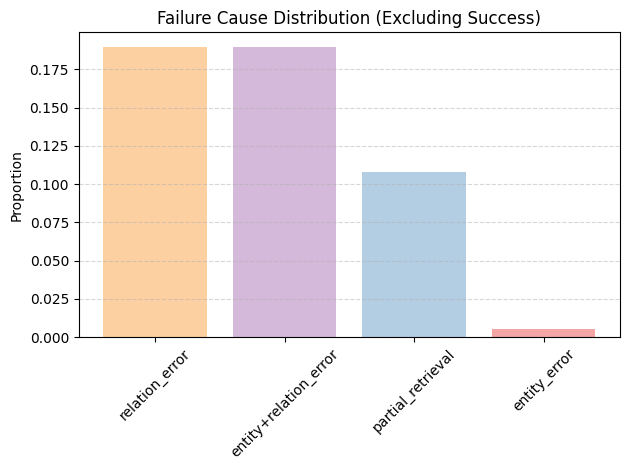

In [48]:
import matplotlib.pyplot as plt

# remove success
overall = df['failure_cause'].value_counts(normalize=True)
overall = overall.drop('success', errors='ignore')

# pastel color map
color_map = {
    'relation_error': '#fdd0a2',
    'entity_error': '#f4a6a6',
    'entity+relation_error': '#d4b9da',
    'partial_retrieval': '#b3cde3',
    'reasoning_error': '#d9d9d9'
}

colors = [color_map.get(k, 'gray') for k in overall.index]

plt.figure()

plt.bar(overall.index, overall.values, color=colors)

plt.xticks(rotation=45)
plt.ylabel('Proportion')
plt.title('Failure Cause Distribution (Excluding Success)')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [49]:
color_map = {
    'success': '#a8ddb5',                # soft green
    'relation_error': '#fdd0a2',         # soft orange
    'entity_error': '#f4a6a6',           # soft red/pink
    'entity+relation_error': '#d4b9da',  # soft purple
    'partial_retrieval': '#b3cde3',      # soft blue
    'reasoning_error': '#d9d9d9'         # light gray
}

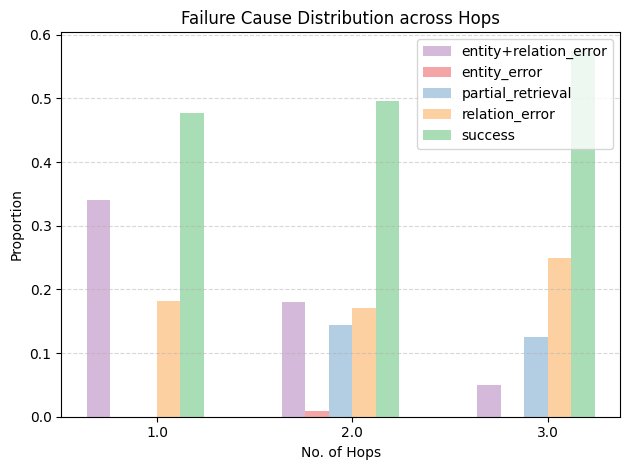

In [50]:
hops_dist = df.groupby('No_of_hops')['failure_cause'] \
              .value_counts(normalize=True) \
              .unstack(fill_value=0)

hops = hops_dist.index
labels = hops_dist.columns

x = np.arange(len(hops))
width = 0.12

plt.figure()

for i, label in enumerate(labels):
    plt.bar(
        x + i * width,
        hops_dist[label],
        width,
        label=label,
        color=color_map.get(label, 'gray')
    )

plt.xticks(x + width * (len(labels)/2), hops)
plt.xlabel('No. of Hops')
plt.ylabel('Proportion')
plt.title('Failure Cause Distribution across Hops')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

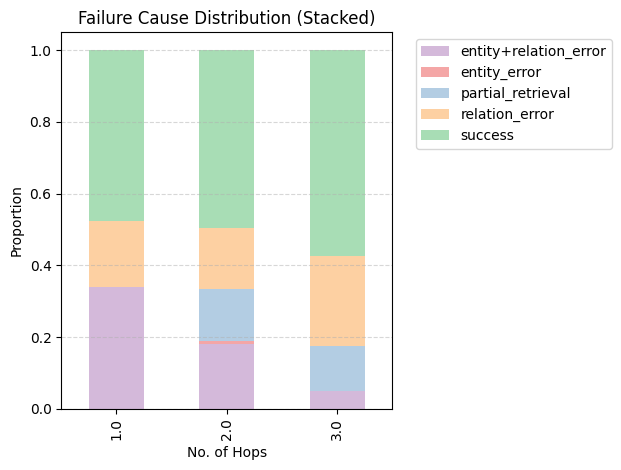

In [51]:
colors = [color_map.get(c, 'gray') for c in hops_dist.columns]

hops_dist.plot(
    kind='bar',
    stacked=True,
    color=colors
)

plt.xlabel('No. of Hops')
plt.ylabel('Proportion')
plt.title('Failure Cause Distribution (Stacked)')

plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

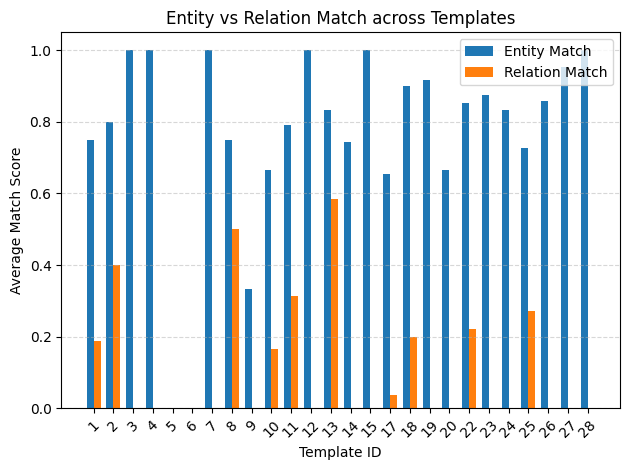

In [52]:
template_agg = df.groupby('template_id')[['entity_match', 'relation_match']].mean()

x = range(len(template_agg))
width = 0.35

plt.figure()

plt.bar(
    [i - width/2 for i in x],
    template_agg['entity_match'],
    width,
    label='Entity Match'
)

plt.bar(
    [i + width/2 for i in x],
    template_agg['relation_match'],
    width,
    label='Relation Match'
)

plt.xticks(x, template_agg.index, rotation=45)
plt.xlabel('Template ID')
plt.ylabel('Average Match Score')
plt.title('Entity vs Relation Match across Templates')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

/tmp/ipykernel_7716/247905878.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


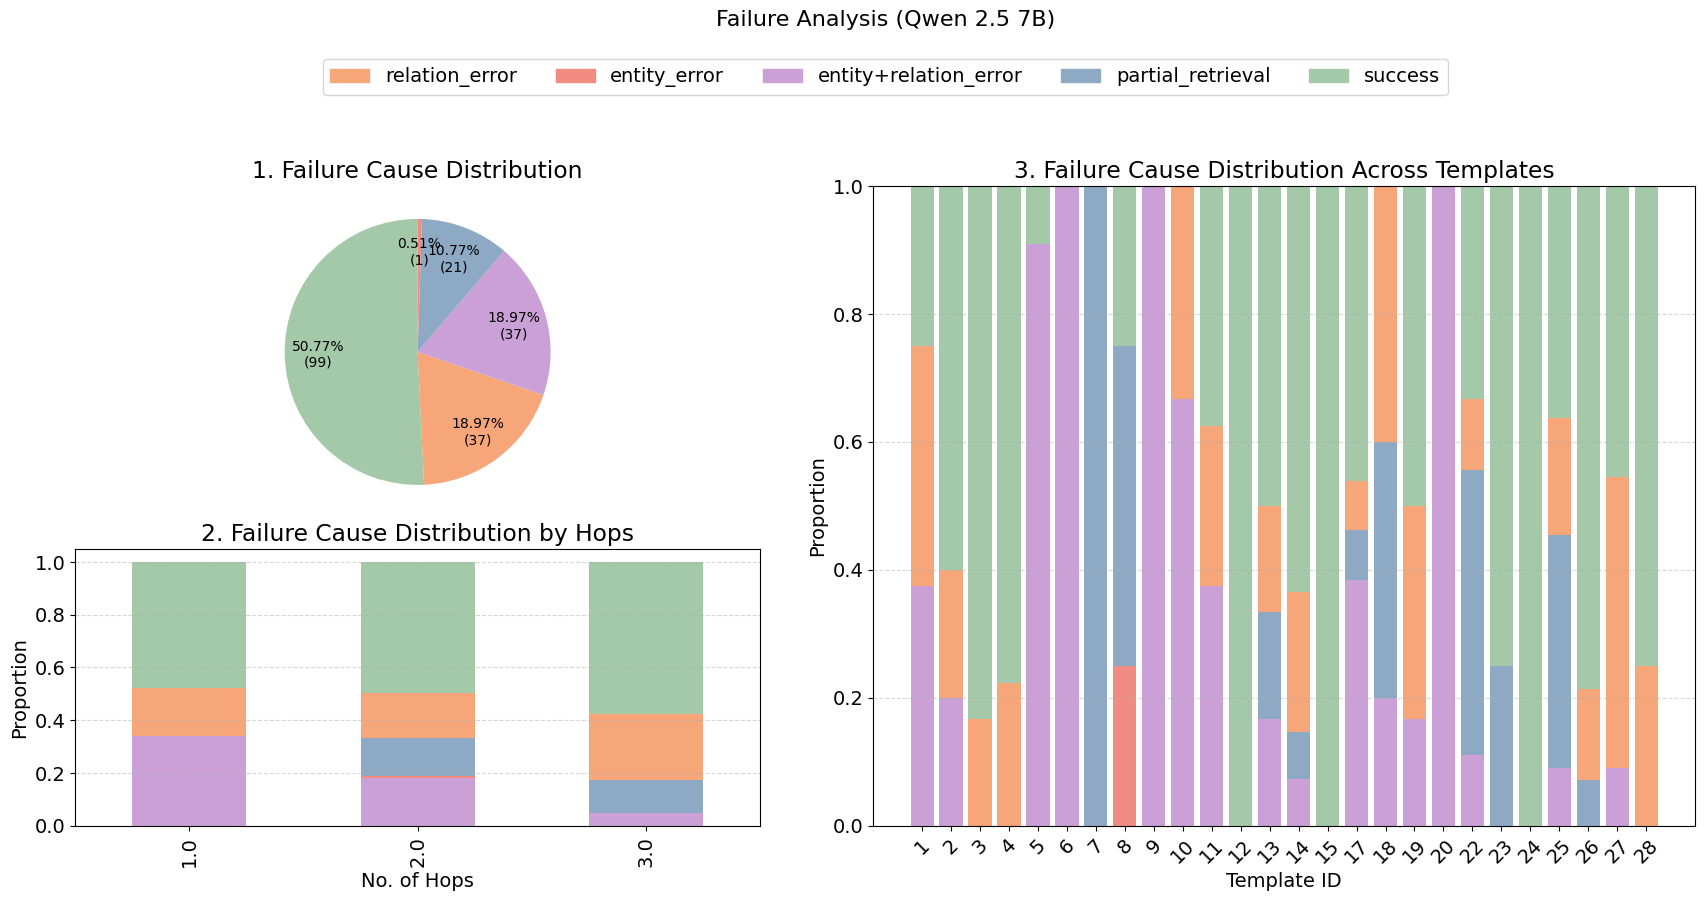

In [68]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({'font.size': 14})

color_map = {
    'relation_error': '#f6a678',        # soft orange
    'entity_error': '#f28b82',          # muted red
    'entity+relation_error': '#cba0d7', # soft lavender/purple
    'partial_retrieval': '#8da9c4',     # muted blue
    'success': '#a3c9a8'                # soft green
}

# --- Pie chart: include success ---
overall = df['failure_cause'].value_counts()
colors_pie = [color_map.get(c, 'gray') for c in overall.index]

# Custom autopct function to show pct and count nicely outside
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.2f}%\n({val})'
    return my_autopct

# --- Hops stacked bar chart ---
colors_bar = [color_map.get(c, 'gray') for c in hops_dist.columns]

# --- Template stacked bar: include success ---
template_counts = df.groupby(['template_id', 'failure_cause']).size().unstack(fill_value=0)
template_norm = template_counts.div(template_counts.sum(axis=1), axis=0)
template_x = range(len(template_norm))

# --- Create figure ---
fig = plt.figure(figsize=(18, 8))


# Overall figure title
fig.suptitle("Failure Analysis (Qwen 2.5 7B)", fontsize=16, y=1.1)

# --- Adjust GridSpec to give more height/width to pie chart ---
gs = gridspec.GridSpec(2, 2, 
                       width_ratios=[1, 1.2], 
                       height_ratios=[1.2, 1],   # top row (pie chart) slightly taller
                       wspace=0.15, hspace=0.1)

# --- Reduce padding around pie chart ---
plt.subplots_adjust(left=0.05, right=0.95, top=0.88, bottom=0.08)

# --- Top-left: Pie chart ---
ax0 = fig.add_subplot(gs[0, 0])
wedges, texts, autotexts = ax0.pie(
    overall.values,
    autopct=make_autopct(overall.values),
    startangle=90,
    colors=colors_pie,
    pctdistance=0.75,
    labeldistance=1.05
)
for t in texts + autotexts:
    t.set_fontsize(10)
ax0.set_title('1. Failure Cause Distribution')



# --- Bottom-left: Hops stacked bar ---
ax1 = fig.add_subplot(gs[1, 0])
hops_dist.plot(kind='bar', stacked=True, color=colors_bar, ax=ax1)
ax1.set_xlabel('No. of Hops')
ax1.set_ylabel('Proportion')
ax1.set_title('2. Failure Cause Distribution by Hops')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Remove internal legend (we'll use unified legend)
if ax1.get_legend() is not None:
    ax1.get_legend().remove()

# --- Right: Template stacked bar ---
ax2 = fig.add_subplot(gs[:, 1])
bottom = [0]*len(template_norm)
for cause in template_norm.columns:
    ax2.bar(template_x, template_norm[cause], bottom=bottom, color=color_map[cause], label=cause)
    bottom = [bottom[j] + template_norm[cause].iloc[j] for j in range(len(bottom))]

ax2.set_xticks(template_x)
ax2.set_xticklabels(template_norm.index, rotation=45)
ax2.set_xlabel('Template ID')
ax2.set_ylabel('Proportion')
ax2.set_title('3. Failure Cause Distribution Across Templates')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Remove internal legend from ax2
if ax2.get_legend() is not None:
    ax2.get_legend().remove()

# --- Unified legend ---
handles = [plt.Rectangle((0,0),1,1, color=color_map[k]) for k in color_map.keys()]
labels = list(color_map.keys())
fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.05), fontsize=14)

# Save figure as SVG
fig.savefig("final_failure_analysis.png", format='png', bbox_inches='tight')

plt.tight_layout()
plt.show()